In [2]:
import pandas as pd 
import numpy as np
import matplotlib as plt 
import seaborn as sns 

In [3]:
train_df= pd.read_csv('KDDTrain+.txt')
test_df = pd.read_csv('KDDTest+.txt')

#class 9 with 8243 instances

In [4]:
# these features are not in the txt format of the dataset, we read the arff format of the dataset to find the appropriate column names for each column so that we can work easily with our data.

column_names = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land',
    'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
    'num_compromised', 'root_shell', 'su_attempted', 'num_root',
    'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds',
    'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate',
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
    'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label','difficulty'
]

train_df.columns= column_names
test_df.columns= column_names

In [5]:
train_df.head(5)



,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.0,0.00,normal,15
1,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.0,0.00,neptune,19
2,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.0,0.01,normal,21
3,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,normal,21
4,0,tcp,private,REJ,0,0,0,0,0,0,...,0.07,0.07,0.00,0.00,0.00,0.00,1.0,1.00,neptune,21


In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125972 entries, 0 to 125971
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125972 non-null  int64  
 1   protocol_type                125972 non-null  object 
 2   service                      125972 non-null  object 
 3   flag                         125972 non-null  object 
 4   src_bytes                    125972 non-null  int64  
 5   dst_bytes                    125972 non-null  int64  
 6   land                         125972 non-null  int64  
 7   wrong_fragment               125972 non-null  int64  
 8   urgent                       125972 non-null  int64  
 9   hot                          125972 non-null  int64  
 10  num_failed_logins            125972 non-null  int64  
 11  logged_in                    125972 non-null  int64  
 12  num_compromised              125972 non-null  int64  
 13 

In [7]:
# this tells us how many object type columns or feature do we have requiring encoding to fit on the Random Forest algo.

obj_column=train_df.select_dtypes(include='object').columns
print(obj_column)
print(len(obj_column))

Index(['protocol_type', 'service', 'flag', 'label'], dtype='object')
4


In [8]:
train_df.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,difficulty
count,125972.000000,1.259720e+05,1.259720e+05,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,...,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000
mean,287.146929,4.556710e+04,1.977927e+04,0.000198,0.022688,0.000111,0.204411,0.001222,0.395739,0.279253,...,115.653725,0.521244,0.082952,0.148379,0.032543,0.284455,0.278487,0.118832,0.120241,19.504056
std,2604.525522,5.870354e+06,4.021285e+06,0.014086,0.253531,0.014366,2.149977,0.045239,0.489011,23.942137,...,110.702886,0.448950,0.188922,0.308998,0.112564,0.444785,0.445670,0.306559,0.319460,2.291512
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000
50%,0.000000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,63.000000,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000
75%,0.000000,2.760000e+02,5.160000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000,21.000000
max,42908.000000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,77.000000,5.000000,1.000000,7479.000000,...,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,21.000000


In [9]:
print(train_df.isnull().sum())

# since this dataset is already perfected from of KDD CUP99, it does not need alterations such as dropping rows but what it may need is encoding.

duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_rate                  0
srv_diff_h

In [10]:
print(train_df['label'].unique())
# to get all the unique values out of every column.

['normal' 'neptune' 'warezclient' 'ipsweep' 'portsweep' 'teardrop' 'nmap'
 'satan' 'smurf' 'pod' 'back' 'guess_passwd' 'ftp_write' 'multihop'
 'rootkit' 'buffer_overflow' 'imap' 'warezmaster' 'phf' 'land'
 'loadmodule' 'spy' 'perl']


In [11]:
print(train_df['protocol_type'].unique())

['udp' 'tcp' 'icmp']


In [12]:
print(train_df['service'].unique())

['other' 'private' 'http' 'remote_job' 'ftp_data' 'name' 'netbios_ns'
 'eco_i' 'mtp' 'telnet' 'finger' 'domain_u' 'supdup' 'uucp_path' 'Z39_50'
 'smtp' 'csnet_ns' 'uucp' 'netbios_dgm' 'urp_i' 'auth' 'domain' 'ftp'
 'bgp' 'ldap' 'ecr_i' 'gopher' 'vmnet' 'systat' 'http_443' 'efs' 'whois'
 'imap4' 'iso_tsap' 'echo' 'klogin' 'link' 'sunrpc' 'login' 'kshell'
 'sql_net' 'time' 'hostnames' 'exec' 'ntp_u' 'discard' 'nntp' 'courier'
 'ctf' 'ssh' 'daytime' 'shell' 'netstat' 'pop_3' 'nnsp' 'IRC' 'pop_2'
 'printer' 'tim_i' 'pm_dump' 'red_i' 'netbios_ssn' 'rje' 'X11' 'urh_i'
 'http_8001' 'aol' 'http_2784' 'tftp_u' 'harvest']


In [13]:
print(train_df['flag'].unique())

['SF' 'S0' 'REJ' 'RSTR' 'SH' 'RSTO' 'S1' 'RSTOS0' 'S3' 'S2' 'OTH']


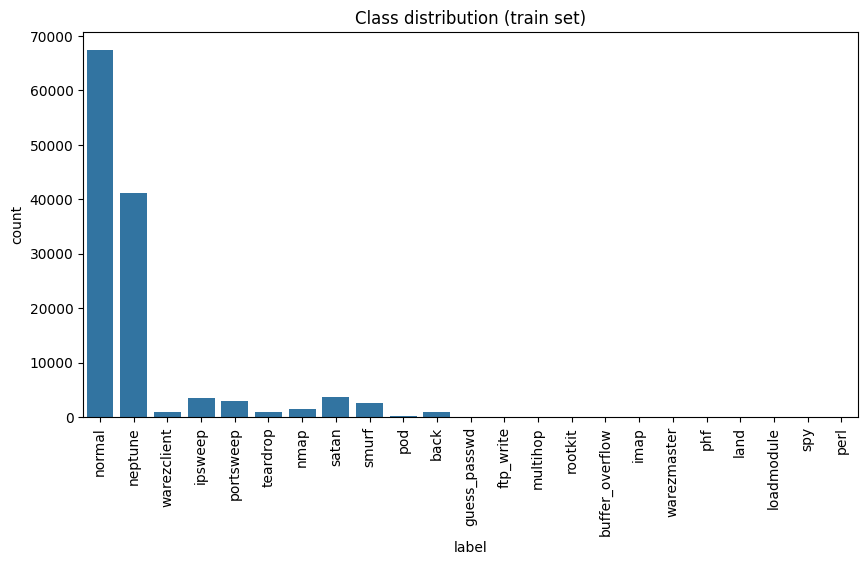

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.countplot(x='label', data=train_df)
plt.xticks(rotation=90)
plt.title('Class distribution (train set)')
plt.show()


In [19]:
plt.figure(figsize=(10,5))
sns.histplot(data=train_df, x='duration', hue='binary_label', bins=50, kde=True)
plt.title('Duration distribution: Normal vs Attack')
plt.show()


ValueError: Could not interpret value `binary_label` for `hue`. An entry with this name does not appear in `data`.

<Figure size 1000x500 with 0 Axes>

In [15]:
# since we are using random forest to find the anomalies we will need our dataset to have all the vakues in numerical form but 4 of our columns "['protocol_type', 'service', 'flag', 'label']" are in object type and hence we need the encoding.
from sklearn.preprocessing import LabelEncoder

train_df_encoded= pd.get_dummies(train_df, columns=['protocol_type', 'service', 'flag'])

le = LabelEncoder()
train_df_encoded['label_encoded'] = le.fit_transform(train_df_encoded['label'])

X = train_df_encoded.drop(['label', 'label_encoded', 'difficulty'], axis=1, errors='ignore')
y = train_df_encoded['label_encoded']

print(train_df_encoded['label_encoded'])

0         11
1          9
2         11
3         11
4          9
          ..
125967     9
125968    11
125969    11
125970     9
125971    11
Name: label_encoded, Length: 125972, dtype: int64


In [16]:
from sklearn.model_selection import train_test_split

X = train_df_encoded.drop(['label', 'label_encoded', 'difficulty'], axis=1, errors='ignore')
y = train_df_encoded['label_encoded']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9984123834094066
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       191
           1       0.83      0.83      0.83         6
           2       0.00      0.00      0.00         2
           3       1.00      1.00      1.00        11
           4       1.00      1.00      1.00         2
           5       0.99      1.00      1.00       720
           6       0.75      0.75      0.75         4
           7       0.00      0.00      0.00         2
           8       0.00      0.00      0.00         1
           9       1.00      1.00      1.00      8243
          10       0.99      0.99      0.99       299
          11       1.00      1.00      1.00     13469
          13       0.00      0.00      0.00         1
          14       1.00      0.97      0.99        40
          15       1.00      0.99      1.00       586
          16       0.00      0.00      0.00         2
          17       1.00     

C:\Users\KUSHAGRA\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\KUSHAGRA\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\KUSHAGRA\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capita

## CLASSIFICATION REPORT SUMMARY

For large classes (e.g., class 9 with 8243 instances), your model performs exceptionally well with near-perfect precision, recall, and F1-score.

For very small classes (like classes with only 1 or 2 instances), the model sometimes predicts none (precision or recall 0). This is common due to very limited data for those classes.

Warnings about "Precision is ill-defined" occur because the model didn’t predict some rare classes at all, so precision can’t be computed.

Macro average gives an equal-weight average across all classes, showing lower overall performance (around 0.73) because rare classes perform poorly.

Weighted average accounts for class frequencies, showing near-perfect overall performance because majority classes dominate.

Model struggles with very rare attack types due to lack of sufficient data.

High accuracy is influenced strongly by dominant classes, so precision and recall for all classes are important for a complete picture.

In [18]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt']
}

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=2, n_jobs=-1, verbose=1, scoring='accuracy')

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best accuracy:", grid_search.best_score_)


Fitting 2 folds for each of 81 candidates, totalling 162 fits
Best parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best accuracy: 0.9978665756157352


## FUTURE IMPROVEMENTS:

Addressing Class Imbalance

Apply oversampling techniques like SMOTE to generate synthetic samples for rare classes.

Use class weighting in the Random Forest to give more importance to minority classes.

Try undersampling the majority classes to balance the dataset.

Feature Engineering and Selection

Analyze feature importance to remove irrelevant features and improve model efficiency.

Create new features capturing temporal or network behavior patterns.

Advanced Models

Explore ensemble methods combining multiple algorithms for better robustness.

Try deep learning architectures like LSTM or CNN for sequence or image-like data if applicable.

Hyperparameter Optimization

Use more exhaustive search methods or Bayesian optimization for even better tuning.

Experiment with different evaluation metrics focusing specifically on recall or F1-score for rare attack types.